# Exploración de Datos (EDA)
## Planeación de Demanda e Inventario

SKUs analizados:
- **19127** – Duracell Batteries AA 40pk
- **294000** – Storage Box 27gal Professional
- **455151** – MS 5-tier Storage Rack


## 1. Importar y configurar

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

SKUS = {
    '19127': 'Duracell Batteries AA 40pk',
    '294000': 'Storage Box 27gal Professional',
    '455151': 'MS 5-tier Storage Rack',
}
COLORS = {'19127': '#1f77b4', '294000': '#ff7f0e', '455151': '#2ca02c'}


## 2. Cargar los archivos

In [4]:
# Ventas históricas
ventas_19127 = pd.read_csv("ventashistoricas_19127.csv")
ventas_294000 = pd.read_csv("ventashistoricas_294000.csv")
ventas_455151 = pd.read_csv("ventashistoricas_455151.csv")

# Órdenes de compra
pos_19127 = pd.read_csv("POs_19127.csv")
pos_294000 = pd.read_csv("POs_2974000.csv")
pos_455151 = pd.read_csv("POs_455151.csv")

# Inventario actual (separador ; y 2 filas de encabezado)
inventario = pd.read_csv("Inventario actual.csv", sep=';', skiprows=2, encoding='utf-8-sig')


In [5]:
# Convertir fechas
for df in [ventas_19127, ventas_294000, ventas_455151]:
    df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

for df in [pos_19127, pos_294000, pos_455151]:
    df['Order_Date'] = pd.to_datetime(df['Order_Date'])
    df['Received Date'] = pd.to_datetime(df['Received Date'])
    df['Revised_Delivery_Date'] = pd.to_datetime(df['Revised_Delivery_Date'])

# Diccionarios de apoyo (para no repetir el código de cada gráfica 3 veces)
ventas = {'19127': ventas_19127, '294000': ventas_294000, '455151': ventas_455151}
pos = {'19127': pos_19127, '294000': pos_294000, '455151': pos_455151}

for sku, nombre in SKUS.items():
    df = ventas[sku]
    print(f"SKU {sku} ({nombre}): {len(df):,} transacciones | "
          f"{df['Transaction_Date'].min().date()} a {df['Transaction_Date'].max().date()}")


SKU 19127 (Duracell Batteries AA 40pk): 146,516 transacciones | 2017-09-01 a 2026-06-18
SKU 294000 (Storage Box 27gal Professional): 132,774 transacciones | 2017-09-01 a 2026-06-18
SKU 455151 (MS 5-tier Storage Rack): 17,177 transacciones | 2023-04-06 a 2026-06-18


## 3. Evolución histórica de la demanda (mensual)

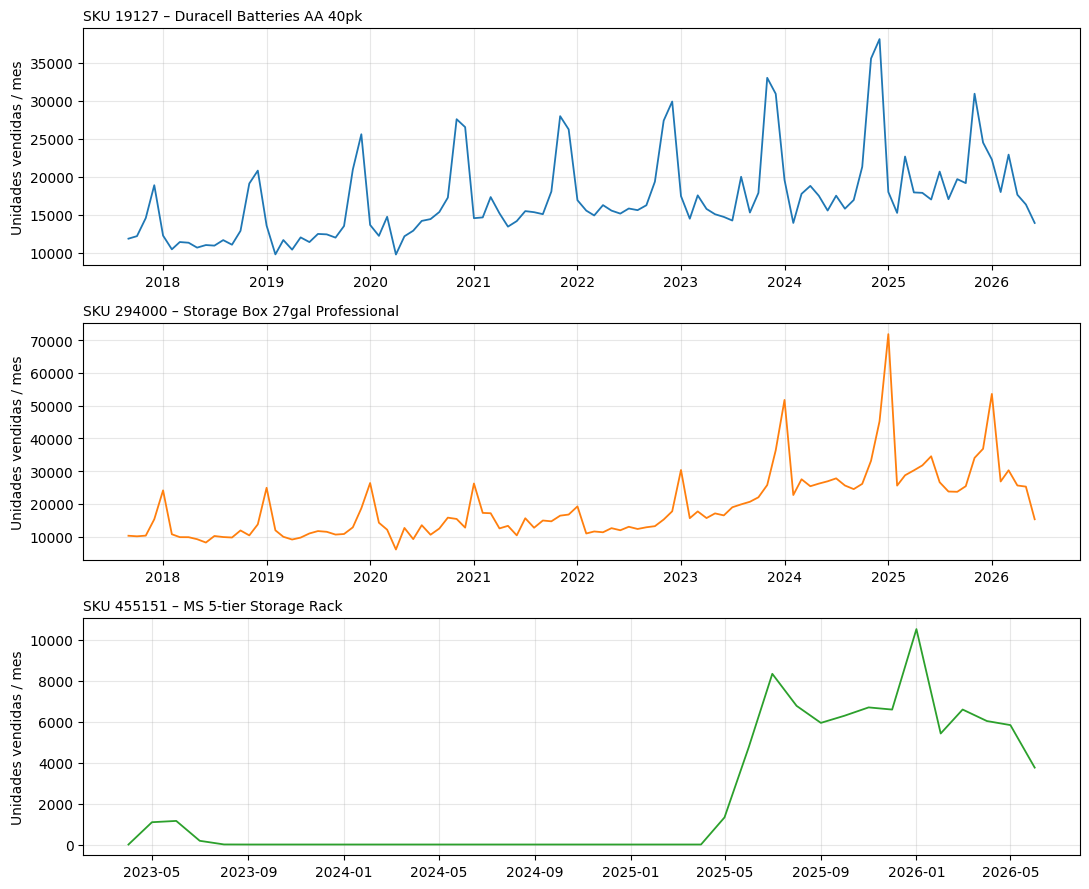

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9))

for ax, (sku, nombre) in zip(axes, SKUS.items()):
    serie = ventas[sku].set_index('Transaction_Date')['Quantity'].resample('MS').sum()
    ax.plot(serie.index, serie.values, color=COLORS[sku], linewidth=1.3)
    ax.set_title(f"SKU {sku} – {nombre}", fontsize=10, loc='left')
    ax.set_ylabel('Unidades vendidas / mes')

plt.tight_layout()
plt.show()


## 4. Estacionalidad: mes y día de la semana

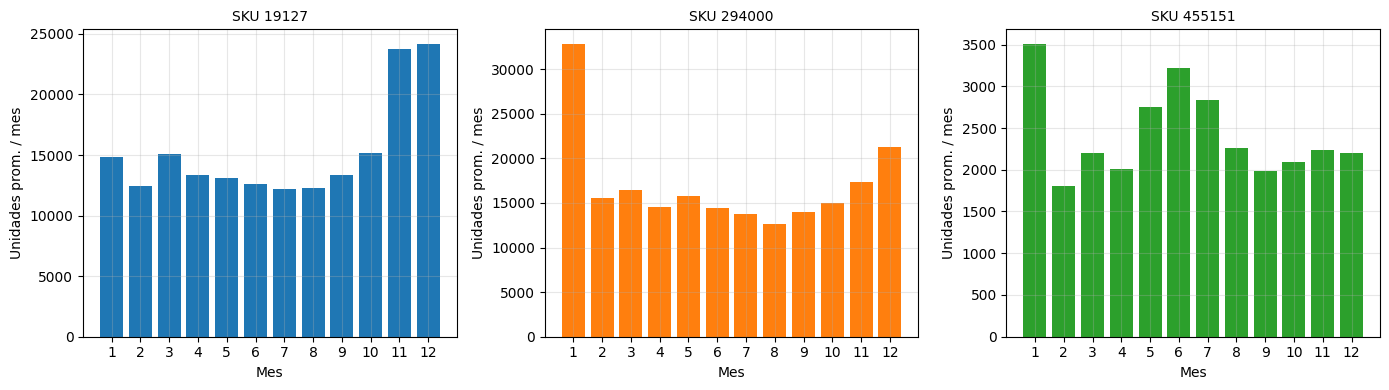

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (sku, nombre) in zip(axes, SKUS.items()):
    df = ventas[sku].copy()
    df['mes'] = df['Transaction_Date'].dt.month
    promedio_mes = df.groupby('mes')['Quantity'].sum() / df['Transaction_Date'].dt.year.nunique()
    ax.bar(promedio_mes.index, promedio_mes.values, color=COLORS[sku])
    ax.set_title(f"SKU {sku}", fontsize=10)
    ax.set_xlabel('Mes')
    ax.set_ylabel('Unidades prom. / mes')
    ax.set_xticks(range(1, 13))

plt.tight_layout()
plt.show()


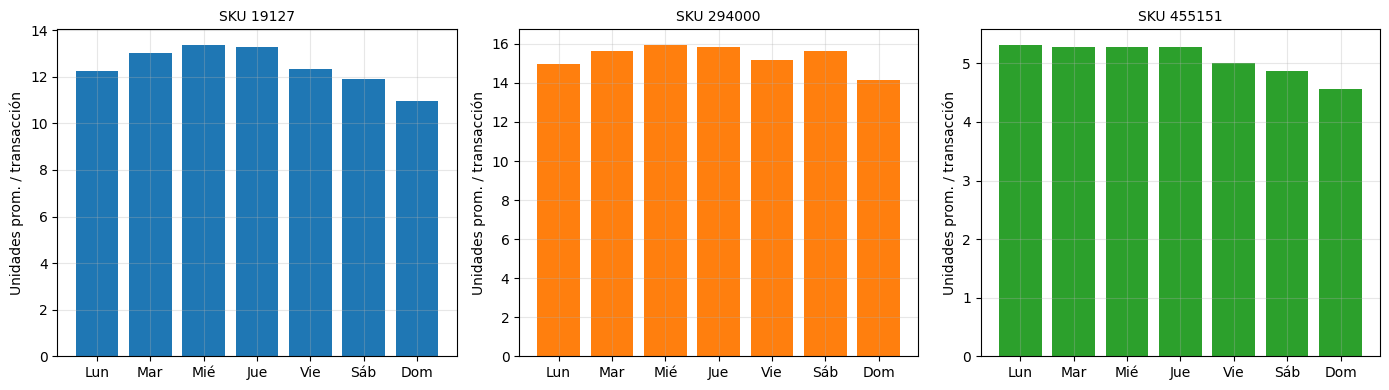

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

for ax, (sku, nombre) in zip(axes, SKUS.items()):
    df = ventas[sku].copy()
    df['dow'] = df['Transaction_Date'].dt.dayofweek
    promedio_dow = df.groupby('dow')['Quantity'].mean()
    ax.bar(promedio_dow.index, promedio_dow.values, color=COLORS[sku])
    ax.set_title(f"SKU {sku}", fontsize=10)
    ax.set_xticks(range(7))
    ax.set_xticklabels(dias)
    ax.set_ylabel('Unidades prom. / transacción')

plt.tight_layout()
plt.show()


## 5. Ventas por país

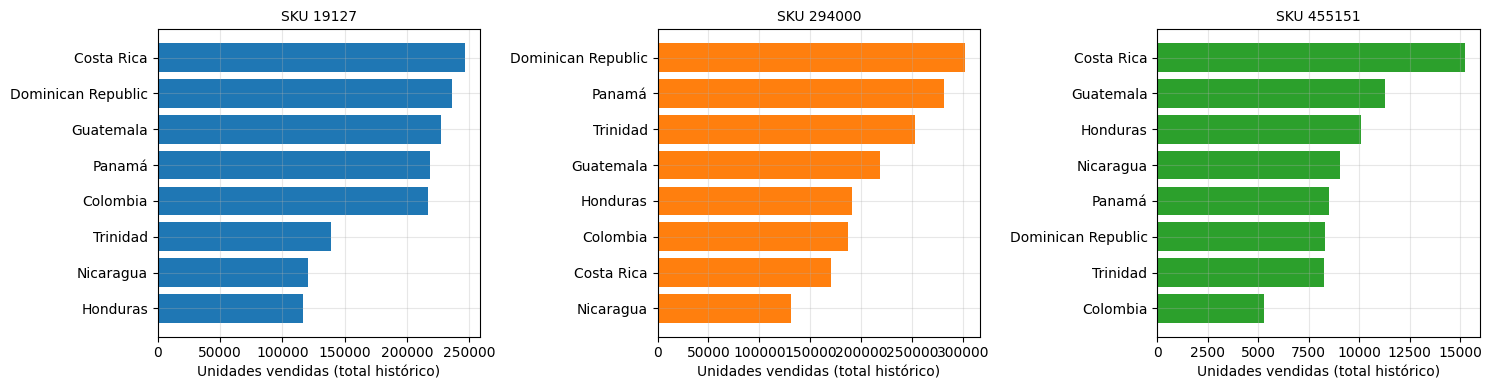

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (sku, nombre) in zip(axes, SKUS.items()):
    df = ventas[sku]
    top_paises = df.groupby('Country')['Quantity'].sum().sort_values(ascending=False).head(8)
    ax.barh(top_paises.index[::-1], top_paises.values[::-1], color=COLORS[sku])
    ax.set_title(f"SKU {sku}", fontsize=10)
    ax.set_xlabel('Unidades vendidas (total histórico)')

plt.tight_layout()
plt.show()


## 6. Órdenes de compra: estado y lead times de proveedores

In [10]:
for sku, df in pos.items():
    proveedores = df['Vendor Name'].unique()
    print(f"SKU {sku}: {len(df):,} órdenes | Proveedor(es): {list(proveedores)} | "
          f"Estado: {df['Status'].value_counts().to_dict()}")


SKU 19127: 3,025 órdenes | Proveedor(es): ['Duracell Distributing Inc.'] | Estado: {'Received': 3022, 'Open': 3}
SKU 294000: 14,043 órdenes | Proveedor(es): ['U.S. Merchants Inc.', 'Costco Wholesale'] | Estado: {'Received': 14033, 'Open': 10}
SKU 455151: 1,539 órdenes | Proveedor(es): ['HoiFat Office Facilities Co., Ltd.'] | Estado: {'Received': 1501, 'Open': 38}


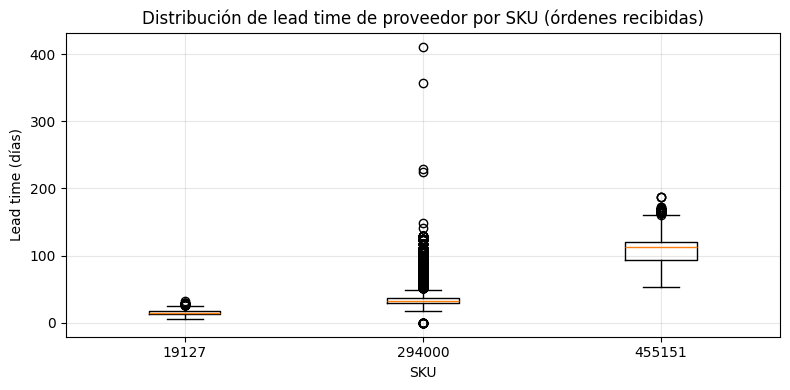

SKU 19127: lead time promedio = 15.2 días, mediana = 14.0 días
SKU 294000: lead time promedio = 36.3 días, mediana = 33.0 días
SKU 455151: lead time promedio = 109.7 días, mediana = 113.0 días


In [11]:
lead_times = {}
for sku, df in pos.items():
    recibidas = df[df['Status'] == 'Received'].copy()
    recibidas['lead_time_dias'] = (recibidas['Received Date'] - recibidas['Order_Date']).dt.days
    lead_times[sku] = recibidas['lead_time_dias']

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([lead_times[s].dropna() for s in SKUS], tick_labels=list(SKUS.keys()))
ax.set_ylabel('Lead time (días)')
ax.set_xlabel('SKU')
ax.set_title('Distribución de lead time de proveedor por SKU (órdenes recibidas)')
plt.tight_layout()
plt.show()

for sku in SKUS:
    print(f"SKU {sku}: lead time promedio = {lead_times[sku].mean():.1f} días, "
          f"mediana = {lead_times[sku].median():.1f} días")


Los lead times son muy distintos entre SKUs. Esta diferencia justifica
tratar cada SKU con su propio modelo y sus propias reglas de reabastecimiento.

In [12]:
print('Órdenes de compra abiertas (pendientes por recibir) por SKU:\n')
for sku, df in pos.items():
    abiertas = df[df['Status'] == 'Open']
    print(f"SKU {sku}: {len(abiertas)} órdenes abiertas, "
          f"{abiertas['Quantity_Open'].sum():,.0f} unidades pendientes por recibir, "
          f"próxima entrega esperada: {abiertas['Revised_Delivery_Date'].min().date() if len(abiertas) else 'N/A'}")


Órdenes de compra abiertas (pendientes por recibir) por SKU:

SKU 19127: 3 órdenes abiertas, 15,456 unidades pendientes por recibir, próxima entrega esperada: 2026-06-25
SKU 294000: 10 órdenes abiertas, 23,760 unidades pendientes por recibir, próxima entrega esperada: 2026-06-25
SKU 455151: 38 órdenes abiertas, 12,727 unidades pendientes por recibir, próxima entrega esperada: 2026-05-25


## 7. Inventario actual

In [13]:
for sku in SKUS:
    n = (inventario['Item number'].astype(str).str.strip() == sku).sum()
    print(f"SKU {sku}: {n} filas (ubicaciones) encontradas en el archivo de inventario")


SKU 19127: 68 filas (ubicaciones) encontradas en el archivo de inventario
SKU 294000: 70 filas (ubicaciones) encontradas en el archivo de inventario
SKU 455151: 71 filas (ubicaciones) encontradas en el archivo de inventario


In [14]:
inventario['[SL] Lead time (days)'] = pd.to_numeric(inventario['[SL] Lead time (days)'], errors='coerce')
inv_skus = inventario[inventario['Item number'].astype(str).str.strip().isin(list(SKUS.keys()))].copy()

resumen_inv = inv_skus.groupby(inv_skus['Item number'].astype(str).str.strip()).agg(
    inventario_total=('End balance', 'sum'),
    ventas_ult_30d=('Sales last 30 Days', 'sum'),
    fcst_prox_30d=('FCST Next 30 Days', 'sum'),
    lead_time_prom=('[SL] Lead time (days)', 'mean'),
    dias_cobertura_prom=('In Loc Days of Supply', 'mean'),
)
resumen_inv


,inventario_total,ventas_ult_30d,fcst_prox_30d,lead_time_prom,dias_cobertura_prom
Item number,,,,,
19127,39226.0,43498.0,54330.353236,14.516129,159.818182
294000,30224.0,61390.0,66062.650000,12.558824,33.500000
455151,5416.0,14220.0,21490.770542,12.652174,12.028986


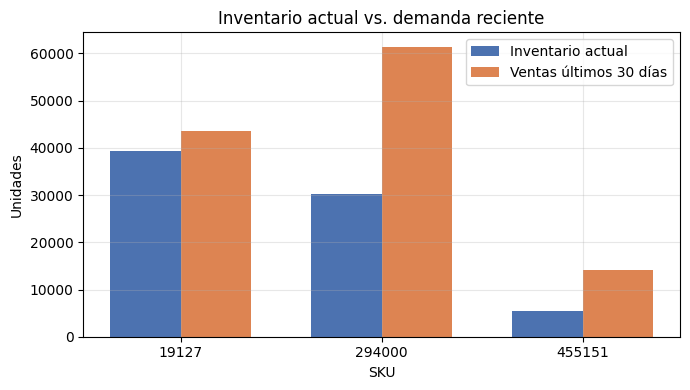

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(resumen_inv))
width = 0.35
ax.bar(x - width/2, resumen_inv['inventario_total'], width, label='Inventario actual', color='#4c72b0')
ax.bar(x + width/2, resumen_inv['ventas_ult_30d'], width, label='Ventas últimos 30 días', color='#dd8452')
ax.set_xticks(x)
ax.set_xticklabels(resumen_inv.index)
ax.set_xlabel('SKU')
ax.set_ylabel('Unidades')
ax.set_title('Inventario actual vs. demanda reciente')
ax.legend()
plt.tight_layout()
plt.show()


## 7.1 Inventario por país y por club

In [16]:
# Mapeo Location -> País (usando Cost_Center de las ventas históricas)
ventas_para_mapa = pd.concat([
    ventas_19127[['Country', 'Cost_Center']],
    ventas_294000[['Country', 'Cost_Center']],
    ventas_455151[['Country', 'Cost_Center']],
]).drop_duplicates()
mapa_pais = dict(zip(ventas_para_mapa['Cost_Center'].astype(str), ventas_para_mapa['Country']))

inv_skus['Pais'] = inv_skus['Location'].astype(str).map(mapa_pais)

# Nos quedamos solo con los clubes (ubicaciones que sí venden y tienen país asignado);
# se excluyen automáticamente los centros de distribución/hubs internos, que no tienen ventas propias.
clubes = inv_skus[inv_skus['Pais'].notna()].copy()
print(f"Clubes identificados: {len(clubes)} (de {len(inv_skus)} filas totales en el inventario)")


Clubes identificados: 170 (de 209 filas totales en el inventario)


### Días de cobertura promedio por país

SKU 19127: 8 de 57 clubes con cobertura muy alta (posible sobreinventario, código 999) -> ['Colombia', 'Costa Rica', 'El Salvador', 'Guatemala', 'Panamá', 'Trinidad']
SKU 294000: 1 de 57 clubes con cobertura muy alta (posible sobreinventario, código 999) -> ['USVI']
SKU 455151: 0 de 56 clubes con cobertura muy alta (posible sobreinventario, código 999) -> []


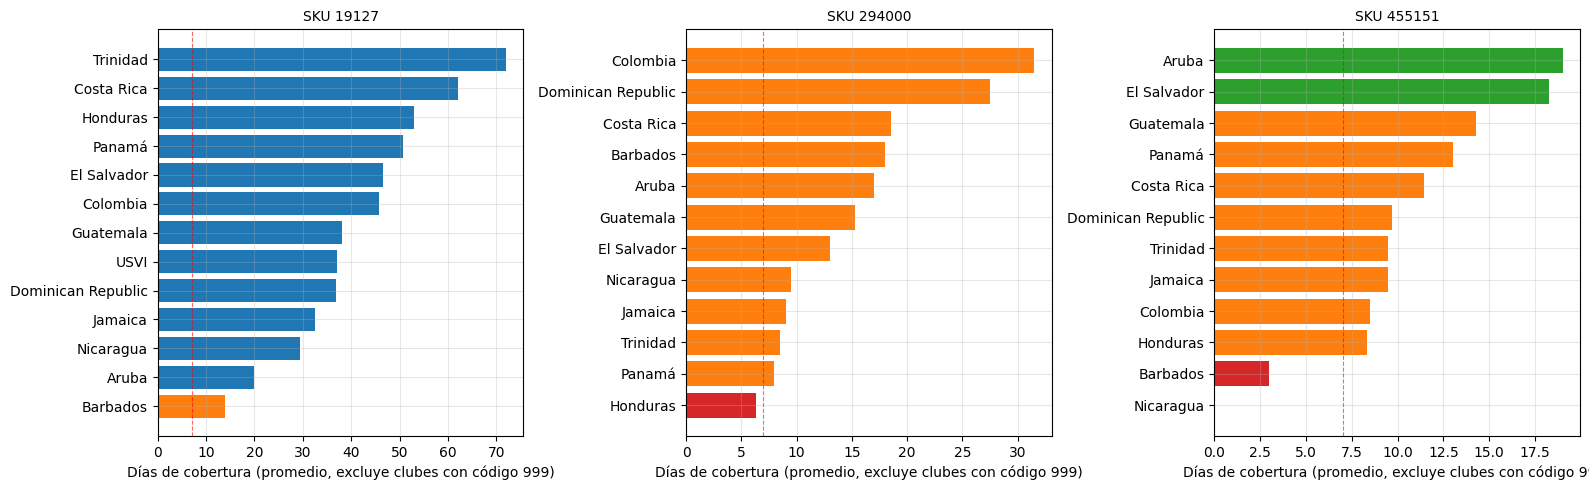

Rojo = menos de 7 días de cobertura promedio | Naranja = entre 7 y 15 días


In [17]:
for sku, nombre in SKUS.items():
    sub = clubes[clubes['Item number'].astype(str).str.strip() == sku]
    tope = sub[sub['In Loc Days of Supply'] >= 999]
    print(f"SKU {sku}: {len(tope)} de {len(sub)} clubes con cobertura muy alta (posible sobreinventario, código 999) "
          f"-> {sorted(tope['Pais'].unique())}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (sku, nombre) in zip(axes, SKUS.items()):
    sub = clubes[(clubes['Item number'].astype(str).str.strip() == sku) &
                 (clubes['In Loc Days of Supply'] < 999)]
    datos = sub.groupby('Pais')['In Loc Days of Supply'].mean().sort_values()
    colores = ['#d62728' if v < 7 else '#ff7f0e' if v < 15 else COLORS[sku] for v in datos.values]
    ax.barh(datos.index, datos.values, color=colores)
    ax.set_title(f"SKU {sku}", fontsize=10)
    ax.set_xlabel('Días de cobertura (promedio, excluye clubes con código 999)')
    ax.axvline(7, color='red', linestyle='--', linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.show()
print("Rojo = menos de 7 días de cobertura promedio | Naranja = entre 7 y 15 días")


### Inventario disponible por país (a nivel club)

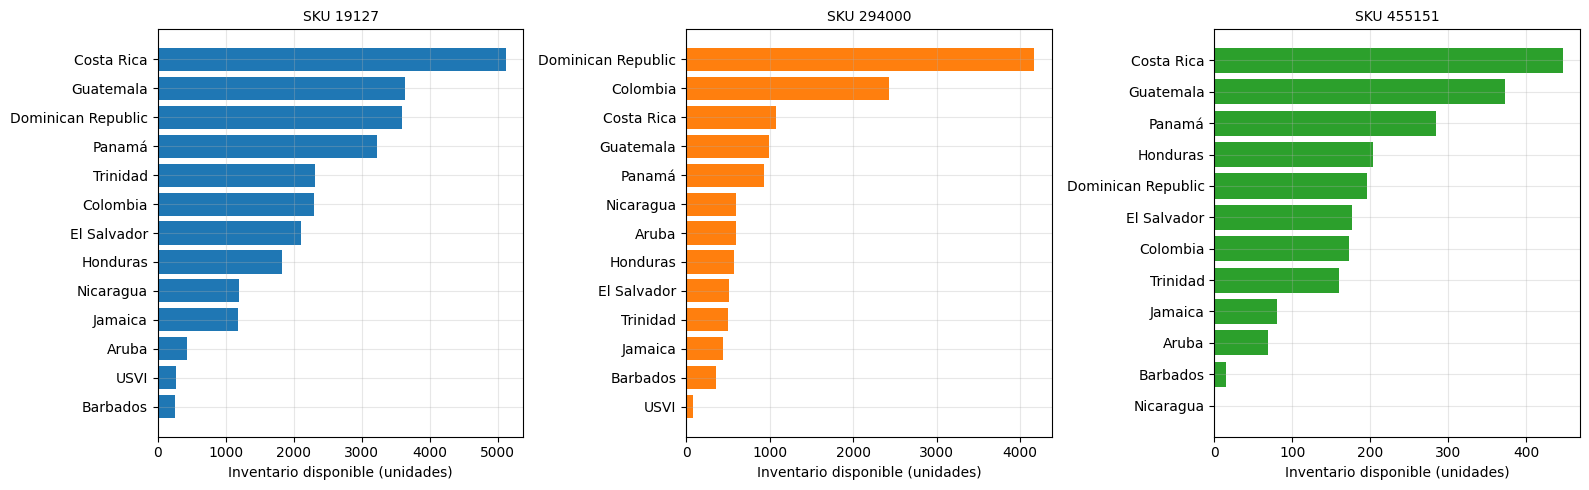

In [18]:
resumen_pais = clubes.groupby(['Item number', 'Pais'])['Unreserved balance'].sum().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (sku, nombre) in zip(axes, SKUS.items()):
    datos = resumen_pais[resumen_pais['Item number'] == sku].sort_values('Unreserved balance', ascending=True)
    ax.barh(datos['Pais'], datos['Unreserved balance'], color=COLORS[sku])
    ax.set_title(f"SKU {sku}", fontsize=10)
    ax.set_xlabel('Inventario disponible (unidades)')

plt.tight_layout()
plt.show()


### Los 10 clubes con menor cobertura por SKU (los que más necesitan atención)

In [19]:
sku_revisar = '455151'   # cambiar aquí por '19127' o '294000' para ver otro SKU

cols_club = ['Location', 'Pais', 'Supplier', 'Unreserved balance', 'Sales last 30 Days',
             'In Loc Days of Supply', 'Open purchase orders', 'In Loc + Open Orders Days of Supply']
peor = (clubes[clubes['Item number'].astype(str).str.strip() == sku_revisar][cols_club]
        .sort_values('In Loc Days of Supply')
        .head(10)
        .copy())

# Buscamos el estado del proveedor interno (hub/DC) de cada uno de estos clubes
sub_completo = inv_skus[inv_skus['Item number'].astype(str).str.strip() == sku_revisar].copy()
sub_completo = sub_completo.set_index(sub_completo['Location'].astype(str))

peor['Cantidad en camino al club'] = peor['Open purchase orders']
peor['Cobertura total del club (con lo en camino)'] = peor['In Loc + Open Orders Days of Supply']
peor['Cantidad en camino al proveedor interno'] = peor['Supplier'].astype(str).map(sub_completo['Open purchase orders'])
peor['Cobertura del proveedor interno (con lo en camino)'] = peor['Supplier'].astype(str).map(sub_completo['In Loc + Open Orders Days of Supply'])

peor[['Location', 'Pais', 'Unreserved balance', 'In Loc Days of Supply',
      'Cantidad en camino al club', 'Cobertura total del club (con lo en camino)',
      'Supplier', 'Cantidad en camino al proveedor interno', 'Cobertura del proveedor interno (con lo en camino)']]


,Location,Pais,Unreserved balance,In Loc Days of Supply,Cantidad en camino al club,Cobertura total del club (con lo en camino),Supplier,Cantidad en camino al proveedor interno,Cobertura del proveedor interno (con lo en camino)
207,8901,Nicaragua,0.0,0.0,0.0,0.0,8924,1035.0,30.0
208,8902,Nicaragua,0.0,0.0,0.0,0.0,8924,1035.0,30.0
141,6101,Colombia,4.0,1.0,27.0,7.0,6121,432.0,64.0
188,6801,Dominican Republic,21.0,3.0,54.0,11.0,6824,405.0,53.0
202,8501,Barbados,15.0,3.0,126.0,33.0,2091,0.0,1.0
146,6106,Colombia,14.0,4.0,18.0,10.0,6121,432.0,64.0
172,6405,Costa Rica,30.0,4.0,27.0,8.0,6424,1242.0,30.0
180,6603,Honduras,38.0,4.0,27.0,7.0,6624,936.0,51.0
154,6204,Panamá,25.0,5.0,36.0,12.0,6224,602.0,46.0
203,8701,Jamaica,41.0,6.0,18.0,9.0,8724,288.0,54.0


Para saber si un club esta realmente en riesgo de quedarse sin inventario, no basta con mirar su stock actual. Tambien hay que revisar si tiene producto en camino y si su proveedor interno puede abastecerlo.

Si el club esta bajo, pero ya tiene unidades en transito, solo se debe hacer seguimiento. Si el club esta bajo y no tiene nada en camino, pero su proveedor interno si tiene inventario, el problema es de redistribucion interna. El riesgo real aparece cuando ni el club ni su proveedor interno tienen inventario disponible o en camino.

En los datos revisados, Nicaragua (8901 y 8902) parece necesitar redistribucion desde su hub (8924), que tiene 1.035 unidades en camino. Barbados (8501) no esta en alerta inmediata, pero su proveedor interno (2091) no tiene inventario en transito, lo que puede generar riesgo en el siguiente ciclo.

Por eso, el tablero deberia marcar primero los clubes con menor cobertura y cruzarlos con el lead time del SKU. Si un producto tarda 110 dias en llegar y un club tiene solo 0 a 3 dias de cobertura, el pedido ya debio haberse gestionado antes.


In [20]:
resumen = []
for sku, nombre in SKUS.items():
    v = ventas[sku]
    demanda_diaria_reciente = (
        v[v['Transaction_Date'] >= v['Transaction_Date'].max() - pd.Timedelta(days=90)]
        .groupby('Transaction_Date')['Quantity'].sum().mean()
    )
    lt = lead_times[sku].mean()
    inv_actual = resumen_inv['inventario_total'].get(sku, np.nan)
    cobertura_dias = inv_actual / demanda_diaria_reciente if pd.notna(inv_actual) and demanda_diaria_reciente else np.nan

    resumen.append({
        'SKU': sku,
        'Producto': nombre,
        'Demanda diaria prom. (últ. 90d)': round(demanda_diaria_reciente, 1),
        'Lead time prom. (días)': round(lt, 1),
        'Inventario actual (unid.)': inv_actual,
        'Cobertura estimada (días)': round(cobertura_dias, 1) if pd.notna(cobertura_dias) else 'Sin dato',
    })

pd.DataFrame(resumen)


,SKU,Producto,Demanda diaria prom. (últ. 90d),Lead time prom. (días),Inventario actual (unid.),Cobertura estimada (días)
0,19127,Duracell Batteries AA 40pk,649.9,15.2,39226.0,60.4
1,294000,Storage Box 27gal Professional,873.2,36.3,30224.0,34.6
2,455151,MS 5-tier Storage Rack,203.3,109.7,5416.0,26.6


## 9. Calidad de datos: valores nulos en ventas históricas

In [21]:
for sku, df in ventas.items():
    nulos = df[df['Quantity'].isnull()]
    print(f"SKU {sku}: {len(nulos)} filas con Quantity nulo")
    if len(nulos):
        print(f"   Transaction_Net_USD en esas filas: min={nulos['Transaction_Net_USD'].min():.1f}, "
              f"max={nulos['Transaction_Net_USD'].max():.1f} (todos negativos)")


SKU 19127: 8 filas con Quantity nulo
   Transaction_Net_USD en esas filas: min=-19.1, max=-13.2 (todos negativos)
SKU 294000: 20 filas con Quantity nulo
   Transaction_Net_USD en esas filas: min=-204.0, max=-12.8 (todos negativos)
SKU 455151: 0 filas con Quantity nulo


Las filas con Quantity nulo tienen siempre un Transaction_Net_USD negativo, son devoluciones (reembolsos) registradas sin cantidad de unidades, no errores de captura aleatorios.

## 10. Demanda histórica por club (no solo por país)

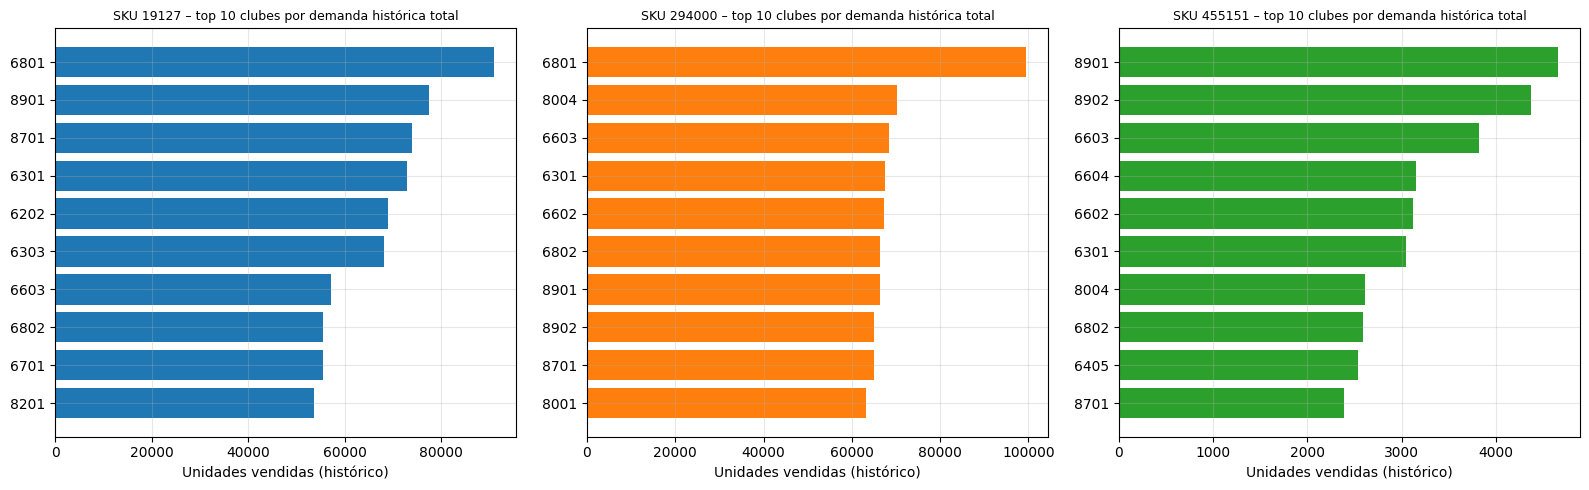

In [23]:
# Demanda total y reciente (últimos 90 días) por club
demanda_club_total = {}
demanda_club_reciente = {}

for sku, df in ventas.items():
    demanda_club_total[sku] = df.groupby('Cost_Center')['Quantity'].sum()
    reciente = df[df['Transaction_Date'] >= df['Transaction_Date'].max() - pd.Timedelta(days=90)]
    demanda_club_reciente[sku] = reciente.groupby('Cost_Center')['Quantity'].sum() / 90  # promedio diario

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (sku, nombre) in zip(axes, SKUS.items()):
    top10 = demanda_club_total[sku].sort_values(ascending=False).head(10)
    ax.barh(top10.index.astype(str)[::-1], top10.values[::-1], color=COLORS[sku])
    ax.set_title(f"SKU {sku} – top 10 clubes por demanda histórica total", fontsize=9)
    ax.set_xlabel('Unidades vendidas (histórico)')

plt.tight_layout()
plt.show()


## 11. Cumplimiento de los proveedores (on-time delivery)

In [26]:
print("¿Los proveedores entregan en la fecha que prometen (Revised_Delivery_Date)?\n")

for sku, df in pos.items():
    recibidas = df[df['Status'] == 'Received'].copy()
    recibidas['retraso_dias'] = (recibidas['Received Date'] - recibidas['Revised_Delivery_Date']).dt.days
    pct_a_tiempo = (recibidas['retraso_dias'] <= 0).mean() * 100
    print(f"SKU {sku}: {pct_a_tiempo:.1f}% de las órdenes llegaron a tiempo o antes | "
          f"retraso promedio = {recibidas['retraso_dias'].mean():.1f} días | "
          f"retraso máximo observado = {recibidas['retraso_dias'].max():.0f} días")


¿Los proveedores entregan en la fecha que prometen (Revised_Delivery_Date)?

SKU 19127: 90.5% de las órdenes llegaron a tiempo o antes | retraso promedio = -0.4 días | retraso máximo observado = 7 días
SKU 294000: 95.6% de las órdenes llegaron a tiempo o antes | retraso promedio = -0.4 días | retraso máximo observado = 47 días
SKU 455151: 73.0% de las órdenes llegaron a tiempo o antes | retraso promedio = -1.5 días | retraso máximo observado = 30 días


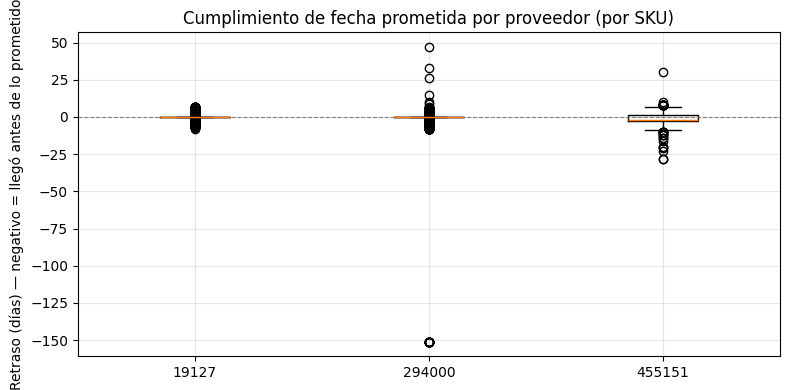

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))
retrasos = []
for sku, df in pos.items():
    recibidas = df[df['Status'] == 'Received'].copy()
    recibidas['retraso_dias'] = (recibidas['Received Date'] - recibidas['Revised_Delivery_Date']).dt.days
    retrasos.append(recibidas['retraso_dias'].dropna())

ax.boxplot(retrasos, tick_labels=list(SKUS.keys()))
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylabel('Retraso (días) — negativo = llegó antes de lo prometido')
ax.set_title('Cumplimiento de fecha prometida por proveedor (por SKU)')
plt.tight_layout()
plt.show()


El proveedor de 455151 (HoiFat, en el extranjero) es el menos confiable,
solo 73% de las órdenes llegan a tiempo, contra 90-96% de los otros dos proveedores. Esto es
relevante para el tablero: la fecha "próxima entrega esperada" para ese SKU debería mostrarse
con algún indicador de incertidumbre, no como un dato fijo y seguro.